In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import itertools
from scipy import stats
import matplotlib.pyplot as plt

### DATA STATIONARITY CHECK

In [ ]:
input_file = 'india_monthly_exports_with_indicators.xlsx'

df = pd.read_excel(input_file, sheet_name='Complete Data')
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'])

monthly = (df.groupby('Date')
             .agg(Export_Value   = ('Export_Value',   'sum'),
                  GDP_Growth      = ('gdp_growth',      'first'),
                  Inflation_Rate = ('Inflation_rate',  'first'),
                  REER           = ('REER',            'first'))
             .reset_index()
             .sort_values('Date'))
monthly.set_index('Date', inplace=True)
monthly.index = pd.DatetimeIndex(monthly.index).to_period('M')

print("RAW DATA SUMMARY")
print(f"  Observations : {len(monthly)}")
print(f"  Date range   : {monthly.index[0]} --> {monthly.index[-1]}")
print(f"  NaN counts   : {dict(monthly.isnull().sum())}")

RAW DATA SUMMARY
  Observations : 96
  Date range   : 2018-01 --> 2025-12
  NaN counts   : {'Export_Value': np.int64(0), 'GDP_Growth': np.int64(0), 'Inflation_Rate': np.int64(0), 'REER': np.int64(0)}


In [ ]:
# INTERPOLATE QUARTERLY GDP growth VALUES TO MONTHLY
monthly['GDP_Growth'] = (
    monthly['GDP_Growth']
    .where(monthly['GDP_Growth'] != monthly['GDP_Growth'].shift(1))
    .interpolate(method='linear')
)

print("INTERPOLATED DATA SUMMARY")
print(f"nan after fix : {monthly['GDP_Growth'].isnull().sum()}")
print(f"\n  First 6 months of GDP Growth after interpolation:")
for idx, val in monthly['GDP_Growth'].head(6).items():
    print(f"    {idx} : {val:.4f}")


INTERPOLATED DATA SUMMARY
nan after fix : 0

  First 6 months of GDP Growth after interpolation:
    2018-01 : 7.7000
    2018-02 : 7.7667
    2018-03 : 7.8333
    2018-04 : 7.9000
    2018-05 : 7.6333
    2018-06 : 7.3667


In [ ]:
#ADF TEST FUNCTION
def run_adf(series, label, alpha=0.05):
    clean = series.dropna()
    stat, pval, lags, nobs, crit, _ = adfuller(clean, autolag='AIC')
    stationary = pval < alpha
    status  = "STATIONARY"     if stationary else "NON-STATIONARY"
    bracket = f"(p={pval:.4f} < alpha={alpha})" if stationary else f"(p={pval:.4f} >= alpha={alpha})"

    print(f"\n Variable: {label}")
    print(f" Series length: {len(clean)}")
    print(f"ADF Statistic: {stat:.6f}")
    print(f"p-value: {pval:.6f}")
    print(f"Lags used: {lags}")
    print(f"Critical vals: 1% {crit['1%']:.4f}|5% {crit['5%']:.4f}|10% {crit['10%']:.4f}")
    print(f"Decision: {status} {bracket}")

    return stationary, pval, lags, nobs


stat_exp,  _, _, _ = run_adf(monthly['Export_Value'],'Export_Value(Level)')
stat_gdp,  _, _, _ = run_adf(monthly['GDP_Growth'],'GDP_Growth(Level)')
stat_inf,  _, _, _ = run_adf(monthly['Inflation_Rate'],'Inflation_Rate(Level)')
stat_reer, _, _, _ = run_adf(monthly['REER'],'REER (Level)')


 Variable: Export_Value(Level)
 Series length: 96
ADF Statistic: -2.015150
p-value: 0.279970
Lags used: 1
Critical vals: 1% -3.5019|5% -2.8928|10% -2.5835
Decision: NON-STATIONARY (p=0.2800 >= alpha=0.05)

 Variable: GDP_Growth(Level)
 Series length: 96
ADF Statistic: -3.902032
p-value: 0.002020
Lags used: 4
Critical vals: 1% -3.5043|5% -2.8939|10% -2.5840
Decision: STATIONARY (p=0.0020 < alpha=0.05)

 Variable: Inflation_Rate(Level)
 Series length: 96
ADF Statistic: -1.577302
p-value: 0.494985
Lags used: 12
Critical vals: 1% -3.5117|5% -2.8970|10% -2.5857
Decision: NON-STATIONARY (p=0.4950 >= alpha=0.05)

 Variable: REER (Level)
 Series length: 96
ADF Statistic: -2.591507
p-value: 0.094765
Lags used: 1
Critical vals: 1% -3.5019|5% -2.8928|10% -2.5835
Decision: NON-STATIONARY (p=0.0948 >= alpha=0.05)


In [ ]:
# adf on differenced export values
d_order = 0
stat_exp_d1 = stat_exp_d2 = False

if stat_exp:
    d_order = 0
    print("\n Export_Value is stationary at level I(0), d = 0")
else:
    print("\n  Export_Value non-stationary at level,testing 1st difference")
    stat_exp_d1, _, _, _ = run_adf(
        monthly['Export_Value'].diff(), 'Export_Value (1st Difference)'
    )
    if stat_exp_d1:
        d_order = 1
    else:
        print("\n Still non-stationary,testing 2nd difference")
        stat_exp_d2, _, _, _ = run_adf(
            monthly['Export_Value'].diff().diff(), 'Export_Value (2nd Difference)'
        )
        if stat_exp_d2:
            d_order = 2
        else:
            print(" 2nd difference still non-stationary")

print(f"\nExport_Value is I({d_order})|d_order = {d_order}")

# adf on differenced exogeneous variables
stat_inf_d1,  _, _, _ = run_adf(
    monthly['Inflation_Rate'].diff(), 'Inflation_Rate (1st Difference)'
)
stat_reer_d1, _, _, _ = run_adf(
    monthly['REER'].diff(),'REER(1st Difference)'
)


  Export_Value non-stationary at level,testing 1st difference

 Variable: Export_Value (1st Difference)
 Series length: 95
ADF Statistic: -9.628958
p-value: 0.000000
Lags used: 1
Critical vals: 1% -3.5027|5% -2.8932|10% -2.5836
Decision: STATIONARY (p=0.0000 < alpha=0.05)

Export_Value is I(1)|d_order = 1

 Variable: Inflation_Rate (1st Difference)
 Series length: 95
ADF Statistic: -3.297942
p-value: 0.014971
Lags used: 11
Critical vals: 1% -3.5117|5% -2.8970|10% -2.5857
Decision: STATIONARY (p=0.0150 < alpha=0.05)

 Variable: REER(1st Difference)
 Series length: 95
ADF Statistic: -8.822451
p-value: 0.000000
Lags used: 0
Critical vals: 1% -3.5019|5% -2.8928|10% -2.5835
Decision: STATIONARY (p=0.0000 < alpha=0.05)


In [ ]:
export_d1 = monthly['Export_Value'].diff()
gdp_lvl   = monthly['GDP_Growth']
inf_d1    = monthly['Inflation_Rate'].diff()
reer_d1   = monthly['REER'].diff()

data_ready = pd.concat(
    [export_d1, gdp_lvl, inf_d1, reer_d1], axis=1
)
data_ready.columns = ['Export_d1', 'GDP_level', 'Inflation_d1', 'REER_d1']
data_ready = data_ready.dropna()

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import itertools
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# CLARIFICATION: IS THIS ARIMAX OR ARIMA?
# =============================================================================
# There is no separate "ARIMAX" class in statsmodels. ARIMAX is just ARIMA
# with exogenous (X) variables added. When you pass exog= to SARIMAX or ARIMA,
# it automatically becomes ARIMAX. We use SARIMAX here because it is the more
# modern and robust implementation. Both give identical results for non-seasonal
# ARIMAX. The model label in the summary will say SARIMAX(p,0,q) -- that is
# correct and expected.

# =============================================================================
# STEP 0: LOAD DATA
# =============================================================================

input_file = 'india_monthly_exports_with_indicators.xlsx'

df = pd.read_excel(input_file, sheet_name='Complete Data')
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'])

monthly = (df.groupby('Date')
             .agg(Export_Value   = ('Export_Value',   'sum'),
                  GDP_Growth      = ('gdp_growth',      'first'),
                  Inflation_Rate = ('Inflation_rate',  'first'),
                  REER           = ('REER',            'first'))
             .reset_index()
             .sort_values('Date'))
monthly.set_index('Date', inplace=True)
monthly.index = pd.DatetimeIndex(monthly.index).to_period('M')

print("=" * 70)
print("DATA LOADED")
print("=" * 70)
print(f"  Observations : {len(monthly)}")
print(f"  Date range   : {monthly.index[0]} --> {monthly.index[-1]}")

# =============================================================================
# STEP 1: GDP INTERPOLATION (quarterly --> monthly)
# =============================================================================
# GDP is quarterly data repeated across 3 months. Interpolate to smooth monthly.
# This makes GDP correctly stationary at level (I(0)).
# See stationarity analysis for full explanation.

monthly['GDP_Growth'] = (
    monthly['GDP_Growth']
    .where(monthly['GDP_Growth'] != monthly['GDP_Growth'].shift(1))
    .interpolate(method='linear')
)

# =============================================================================
# STEP 2: BUILD data_ready
# =============================================================================
# Each variable at its correct integration order from stationarity analysis:
#
#   Export_Value   --> 1st difference  (I(1)) -- this is our endog Y
#   GDP_Growth     --> LEVEL           (I(0)) -- stationary as-is after interpolation
#   Inflation_Rate --> 1st difference  (I(1))
#   REER           --> 1st difference  (I(1))
#
# All are combined via pd.concat on the shared PeriodIndex, then dropna()
# drops the single 2018-01 row (NaN from differencing Export/Inflation/REER).
# Result: 95 perfectly aligned observations, zero NaNs.
#
# DO NOT difference GDP -- it is I(0). Differencing it causes over-differencing
# (p-value becomes 0.061, non-stationary). GDP is passed in LEVELS to the model.

export_d1 = monthly['Export_Value'].diff()
gdp_lvl   = monthly['GDP_Growth']            # NO differencing -- I(0)
inf_d1    = monthly['Inflation_Rate'].diff()
reer_d1   = monthly['REER'].diff()

data_ready = pd.concat([export_d1, gdp_lvl, inf_d1, reer_d1], axis=1)
data_ready.columns = ['Export_d1', 'GDP_level', 'Inflation_d1', 'REER_d1']
data_ready = data_ready.dropna()

print("\n" + "=" * 70)
print("data_ready -- ALIGNED DATASET")
print("=" * 70)
print(f"  Shape      : {data_ready.shape}")
print(f"  Date range : {data_ready.index[0]} --> {data_ready.index[-1]}")
print(f"  NaN count  : {data_ready.isnull().sum().sum()}  (must be 0)")
print(f"\n  Variables:")
print(f"    Export_d1    : delta(Export_Value)  -- endog Y, pre-differenced")
print(f"    GDP_level    : GDP_Growth at level  -- exog, I(0), no diff needed")
print(f"    Inflation_d1 : delta(Inflation)     -- exog, I(1), differenced")
print(f"    REER_d1      : delta(REER)          -- exog, I(1), differenced")

# Split Y and exog
Y    = data_ready['Export_d1']
exog = data_ready[['GDP_level', 'Inflation_d1', 'REER_d1']]

# =============================================================================
# STEP 3: GRID SEARCH -- BEST ARIMAX(p, 0, q)
# =============================================================================
# d=0 because Y (Export_d1) is ALREADY pre-differenced.
# Setting d=1 here would double-difference the endog -- do NOT do that.
# Grid searches p in [0,3] and q in [0,3] --> 16 candidate models.

print("\n" + "=" * 70)
print("GRID SEARCH: ARIMAX(p, 0, q)")
print("=" * 70)
print("  d=0 in all models -- Y is already pre-differenced (d(Export))")
print(f"  Searching p in [0,1,2,3] x q in [0,1,2,3] = 16 models\n")

results_list = []

for p, q in itertools.product(range(0, 4), range(0, 4)):
    try:
        model = SARIMAX(
            endog  = Y,
            exog   = exog,
            order  = (p, 0, q),
            trend  = 'n',
            enforce_stationarity  = True,
            enforce_invertibility = True
        )
        fit = model.fit(disp=False)
        results_list.append({
            'p': p, 'q': q,
            'AIC': round(fit.aic, 2),
            'BIC': round(fit.bic, 2),
            'HQIC': round(fit.hqic, 2),
            'LogLik': round(fit.llf, 2),
            'Converged': True
        })
        print(f"  ARIMAX({p},0,{q})  AIC={fit.aic:>10.2f}  BIC={fit.bic:>10.2f}  HQIC={fit.hqic:>10.2f}")

    except Exception as e:
        results_list.append({
            'p': p, 'q': q,
            'AIC': np.nan, 'BIC': np.nan, 'HQIC': np.nan,
            'LogLik': np.nan, 'Converged': False
        })
        print(f"  ARIMAX({p},0,{q})  FAILED: {str(e)[:50]}")

grid_df = (pd.DataFrame(results_list)
             .dropna(subset=['AIC'])
             .sort_values('AIC')
             .reset_index(drop=True))

print(f"\n{'='*70}")
print("TOP 10 MODELS BY AIC")
print(f"{'='*70}")
print(grid_df.head(10).to_string(index=False))

best    = grid_df.iloc[0]
best_p  = int(best.p)
best_q  = int(best.q)

print(f"\n{'='*70}")
print(f"BEST MODEL: ARIMAX({best_p}, 0, {best_q})")
print(f"{'='*70}")
print(f"  AIC    = {best.AIC}")
print(f"  BIC    = {best.BIC}")
print(f"  HQIC   = {best.HQIC}")
print(f"  LogLik = {best.LogLik}")

# =============================================================================
# STEP 4: FIT BEST MODEL ON FULL DATA
# =============================================================================

print(f"\n{'='*70}")
print(f"FITTING BEST MODEL: ARIMAX({best_p}, 0, {best_q}) ON FULL DATA")
print(f"{'='*70}\n")

best_fit = SARIMAX(
    endog  = Y,
    exog   = exog,
    order  = (best_p, 0, best_q),
    trend  = 'n',
    enforce_stationarity  = True,
    enforce_invertibility = True
).fit(disp=False)

print(best_fit.summary())

# =============================================================================
# STEP 5: RESIDUAL DIAGNOSTICS
# =============================================================================

print(f"\n{'='*70}")
print("RESIDUAL DIAGNOSTICS")
print(f"{'='*70}")

resid = best_fit.resid.dropna()

# Ljung-Box test -- H0: residuals are white noise (no autocorrelation)
lb = acorr_ljungbox(resid, lags=[5, 10, 15, 20], return_df=True)
print("\nLjung-Box Test  (H0: no autocorrelation in residuals)")
print("  p > 0.05 at all lags = residuals are white noise = GOOD")
print(lb.to_string())

# Jarque-Bera test -- H0: residuals are normally distributed
jb_stat, jb_p = stats.jarque_bera(resid)
sk_val = stats.skew(resid)
ku_val = stats.kurtosis(resid)

print(f"\nJarque-Bera Test  (H0: residuals are normally distributed)")
print(f"  Statistic : {jb_stat:.6f}")
print(f"  p-value   : {jb_p:.6f}")
if jb_p > 0.05:
    print(f"  PASS -- Residuals are normally distributed (p={jb_p:.4f} > 0.05)")
else:
    print(f"  FAIL -- Residuals are NOT normally distributed (p={jb_p:.4f} <= 0.05)")
    print(f"  Note: ARIMAX is still valid; normality affects CI interpretation only")

print(f"\n  Skewness : {sk_val:.4f}  (0 = symmetric)")
print(f"  Kurtosis : {ku_val:.4f}  (0 = normal tails, excess kurtosis)")

# =============================================================================
# STEP 6: ACCURACY METRICS (IN-SAMPLE AND OUT-OF-SAMPLE ON LEVEL SCALE)
# =============================================================================
# We report accuracy on the ORIGINAL LEVEL (USD M) of Export_Value, not on
# the differenced series. This gives meaningful, interpretable error numbers.
#
# To recover level from fitted/predicted differences:
#   level[t] = level[t-1] + d(level)[t]
#   --> level[t] = base + cumsum(d(level)[t=1..T])

print(f"\n{'='*70}")
print("ACCURACY METRICS  (reported on ORIGINAL LEVEL scale, USD M)")
print(f"{'='*70}")

# --- In-sample ---
fitted_d   = best_fit.fittedvalues.dropna()
common_idx = Y.index.intersection(fitted_d.index)

# Base: Export value one period before the first fitted index
first_pos  = monthly.index.get_loc(common_idx[0])
base_is    = monthly['Export_Value'].iloc[first_pos - 1]

y_true_is  = monthly['Export_Value'].loc[common_idx].values
y_pred_is  = base_is + fitted_d.loc[common_idx].values.cumsum()

rmse_is = np.sqrt(mean_squared_error(y_true_is, y_pred_is))
mae_is  = mean_absolute_error(y_true_is, y_pred_is)
mape_is = np.mean(np.abs((y_true_is - y_pred_is) / y_true_is)) * 100
r2_is   = 1 - (np.sum((y_true_is - y_pred_is)**2) /
               np.sum((y_true_is - y_true_is.mean())**2))

print(f"\nIn-Sample Validation  (n = {len(y_true_is)} months):")
print(f"  RMSE : {rmse_is:>12.2f}  USD M")
print(f"  MAE  : {mae_is:>12.2f}  USD M")
print(f"  MAPE : {mape_is:>12.2f}  %")
print(f"  R²   : {r2_is:>12.4f}")
print(f"\n  Note: R² and MAPE on cumulative-sum reconstruction of level can")
print(f"  look worse than on the differenced series -- this is expected.")
print(f"  The OOS MAPE on level is the more meaningful accuracy measure.")

# --- Out-of-sample (last 12 months held out) ---
N_TEST  = 12
Y_train = Y.iloc[:-N_TEST]
Y_test  = Y.iloc[-N_TEST:]
X_train = exog.iloc[:-N_TEST]
X_test  = exog.iloc[-N_TEST:]

oos_fit = SARIMAX(
    endog  = Y_train,
    exog   = X_train,
    order  = (best_p, 0, best_q),
    trend  = 'n',
    enforce_stationarity  = True,
    enforce_invertibility = True
).fit(disp=False)

oos_fc      = oos_fit.get_forecast(steps=N_TEST, exog=X_test)
oos_pred_d  = oos_fc.predicted_mean

# Base for OOS level recovery
base_oos         = monthly['Export_Value'].iloc[-(N_TEST + 1)]
y_test_level     = monthly['Export_Value'].iloc[-N_TEST:].values
y_pred_oos_level = base_oos + oos_pred_d.values.cumsum()

rmse_oos = np.sqrt(mean_squared_error(y_test_level, y_pred_oos_level))
mae_oos  = mean_absolute_error(y_test_level, y_pred_oos_level)
mape_oos = np.mean(np.abs((y_test_level - y_pred_oos_level) / y_test_level)) * 100

print(f"\nOut-of-Sample Validation  (last n = {N_TEST} months held out):")
print(f"  RMSE : {rmse_oos:>12.2f}  USD M")
print(f"  MAE  : {mae_oos:>12.2f}  USD M")
print(f"  MAPE : {mape_oos:>12.2f}  %")

print(f"\n  OOS Actual vs Predicted (level, USD M):")
print(f"  {'Month':<12} {'Actual':>12} {'Predicted':>12} {'Error':>12}")
print(f"  {'-'*50}")
oos_months = monthly.index[-N_TEST:]
for i, m in enumerate(oos_months):
    err = y_test_level[i] - y_pred_oos_level[i]
    print(f"  {str(m):<12} {y_test_level[i]:>12.2f} {y_pred_oos_level[i]:>12.2f} {err:>12.2f}")

# =============================================================================
# STEP 7: 12-MONTH FUTURE FORECAST
# =============================================================================
# Future exog assumptions:
#   GDP_level    : last observed GDP_Growth level held constant
#                  (most neutral assumption without external GDP projections)
#   Inflation_d1 : 0.0 -- assumes Inflation level stays flat (no further change)
#   REER_d1      : 0.0 -- assumes REER level stays flat (no further change)
#
# Setting diff variables to 0 means: we assume the LEVEL of Inflation and REER
# in future months equals the last observed level (no change).
# If you have external projections for these variables, replace 0.0 with them.

print(f"\n{'='*70}")
print("12-MONTH FUTURE FORECAST  (Jan 2026 - Dec 2026)")
print(f"{'='*70}")

last_gdp_level = monthly['GDP_Growth'].iloc[-1]

print(f"\n  Exog assumptions for forecast period:")
print(f"    GDP_level    = {last_gdp_level:.4f}  (last observed, held constant)")
print(f"    Inflation_d1 = 0.0000  (Inflation level assumed flat)")
print(f"    REER_d1      = 0.0000  (REER level assumed flat)")
print(f"  Replace with actual projections if available.")

fut_exog = pd.DataFrame({
    'GDP_level':    [last_gdp_level] * 12,
    'Inflation_d1': [0.0] * 12,
    'REER_d1':      [0.0] * 12
})

future_fc   = best_fit.get_forecast(steps=12, exog=fut_exog)
future_d    = future_fc.predicted_mean
future_ci_d = future_fc.conf_int(alpha=0.05)

# Recover level from predicted differences
last_export  = monthly['Export_Value'].iloc[-1]
future_level = last_export + future_d.cumsum()
future_lo    = last_export + future_ci_d.iloc[:, 0].cumsum()
future_hi    = last_export + future_ci_d.iloc[:, 1].cumsum()

future_periods = pd.period_range(
    start=monthly.index[-1] + 1,
    periods=12,
    freq='M'
)

print(f"\n  {'Month':<12} {'Forecast (USD M)':>18} {'Lower 95%':>15} {'Upper 95%':>15}")
print(f"  {'-'*62}")
for i, p in enumerate(future_periods):
    print(f"  {str(p):<12} {future_level.iloc[i]:>18.2f} "
          f"{future_lo.iloc[i]:>15.2f} {future_hi.iloc[i]:>15.2f}")

print(f"\n  Note: Prediction intervals widen over time -- this is correct.")
print(f"  Uncertainty compounds as the forecast horizon extends.")

print(f"\n{'='*70}")
print("ANALYSIS COMPLETE")
print(f"{'='*70}")

DATA LOADED
  Observations : 96
  Date range   : 2018-01 --> 2025-12

data_ready -- ALIGNED DATASET
  Shape      : (95, 4)
  Date range : 2018-02 --> 2025-12
  NaN count  : 0  (must be 0)

  Variables:
    Export_d1    : delta(Export_Value)  -- endog Y, pre-differenced
    GDP_level    : GDP_Growth at level  -- exog, I(0), no diff needed
    Inflation_d1 : delta(Inflation)     -- exog, I(1), differenced
    REER_d1      : delta(REER)          -- exog, I(1), differenced

GRID SEARCH: ARIMAX(p, 0, q)
  d=0 in all models -- Y is already pre-differenced (d(Export))
  Searching p in [0,1,2,3] x q in [0,1,2,3] = 16 models

  ARIMAX(0,0,0)  AIC=   1825.71  BIC=   1835.92  HQIC=   1829.83
  ARIMAX(0,0,1)  AIC=   1803.48  BIC=   1816.25  HQIC=   1808.64
  ARIMAX(0,0,2)  AIC=   1804.99  BIC=   1820.32  HQIC=   1811.18
  ARIMAX(0,0,3)  AIC=   1806.03  BIC=   1823.90  HQIC=   1813.25
  ARIMAX(1,0,0)  AIC=   1807.21  BIC=   1819.98  HQIC=   1812.37
  ARIMAX(1,0,1)  AIC=   1805.22  BIC=   1820.55  H

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import itertools
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# CLARIFICATION: IS THIS ARIMAX OR ARIMA?
# =============================================================================
# There is no separate "ARIMAX" class in statsmodels. ARIMAX is just ARIMA
# with exogenous (X) variables added. When you pass exog= to SARIMAX or ARIMA,
# it automatically becomes ARIMAX. We use SARIMAX here because it is the more
# modern and robust implementation. Both give identical results for non-seasonal
# ARIMAX. The model label in the summary will say SARIMAX(p,0,q) -- that is
# correct and expected.

# =============================================================================
# STEP 0: LOAD DATA
# =============================================================================

input_file = 'india_monthly_exports_with_indicators.xlsx'

df = pd.read_excel(input_file, sheet_name='Complete Data')
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'])

monthly = (df.groupby('Date')
             .agg(Export_Value   = ('Export_Value',   'sum'),
                  GDP_Growth      = ('gdp_growth',      'first'),
                  Inflation_Rate = ('Inflation_rate',  'first'),
                  REER           = ('REER',            'first'))
             .reset_index()
             .sort_values('Date'))
monthly.set_index('Date', inplace=True)
monthly.index = pd.DatetimeIndex(monthly.index).to_period('M')

print("=" * 70)
print("DATA LOADED")
print("=" * 70)
print(f"  Observations : {len(monthly)}")
print(f"  Date range   : {monthly.index[0]} --> {monthly.index[-1]}")

# =============================================================================
# STEP 1: GDP INTERPOLATION (quarterly --> monthly)
# =============================================================================
# GDP is quarterly data repeated across 3 months. Interpolate to smooth monthly.
# This makes GDP correctly stationary at level (I(0)).
# See stationarity analysis for full explanation.

monthly['GDP_Growth'] = (
    monthly['GDP_Growth']
    .where(monthly['GDP_Growth'] != monthly['GDP_Growth'].shift(1))
    .interpolate(method='linear')
)

# =============================================================================
# STEP 2: BUILD data_ready
# =============================================================================
# Each variable at its correct integration order from stationarity analysis:
#
#   Export_Value   --> 1st difference  (I(1)) -- this is our endog Y
#   GDP_Growth     --> LEVEL           (I(0)) -- stationary as-is after interpolation
#   Inflation_Rate --> 1st difference  (I(1))
#   REER           --> 1st difference  (I(1))
#
# All are combined via pd.concat on the shared PeriodIndex, then dropna()
# drops the single 2018-01 row (NaN from differencing Export/Inflation/REER).
# Result: 95 perfectly aligned observations, zero NaNs.
#
# DO NOT difference GDP -- it is I(0). Differencing it causes over-differencing
# (p-value becomes 0.061, non-stationary). GDP is passed in LEVELS to the model.

export_d1 = monthly['Export_Value'].diff()
gdp_lvl   = monthly['GDP_Growth']            # NO differencing -- I(0)
inf_d1    = monthly['Inflation_Rate'].diff()
reer_d1   = monthly['REER'].diff()

data_ready = pd.concat([export_d1, gdp_lvl, inf_d1, reer_d1], axis=1)
data_ready.columns = ['Export_d1', 'GDP_level', 'Inflation_d1', 'REER_d1']
data_ready = data_ready.dropna()

print("\n" + "=" * 70)
print("data_ready -- ALIGNED DATASET")
print("=" * 70)
print(f"  Shape      : {data_ready.shape}")
print(f"  Date range : {data_ready.index[0]} --> {data_ready.index[-1]}")
print(f"  NaN count  : {data_ready.isnull().sum().sum()}  (must be 0)")
print(f"\n  Variables:")
print(f"    Export_d1    : delta(Export_Value)  -- endog Y, pre-differenced")
print(f"    GDP_level    : GDP_Growth at level  -- exog, I(0), no diff needed")
print(f"    Inflation_d1 : delta(Inflation)     -- exog, I(1), differenced")
print(f"    REER_d1      : delta(REER)          -- exog, I(1), differenced")

# Split Y and exog
Y    = data_ready['Export_d1']
exog = data_ready[['GDP_level', 'Inflation_d1', 'REER_d1']]

# =============================================================================
# STEP 3: GRID SEARCH -- BEST ARIMAX(p, 0, q)
# =============================================================================
# d=0 because Y (Export_d1) is ALREADY pre-differenced.
# Setting d=1 here would double-difference the endog -- do NOT do that.
# Grid searches p in [0,3] and q in [0,3] --> 16 candidate models.

print("\n" + "=" * 70)
print("GRID SEARCH: ARIMAX(p, 0, q)")
print("=" * 70)
print("  d=0 in all models -- Y is already pre-differenced (d(Export))")
print(f"  Searching p in [0,1,2,3] x q in [0,1,2,3] = 16 models\n")

results_list = []

for p, q in itertools.product(range(0, 4), range(0, 4)):
    try:
        model = SARIMAX(
            endog  = Y,
            exog   = exog,
            order  = (p, 0, q),
            trend  = 'n',
            enforce_stationarity  = True,
            enforce_invertibility = True
        )
        fit = model.fit(disp=False)
        results_list.append({
            'p': p, 'q': q,
            'AIC': round(fit.aic, 2),
            'BIC': round(fit.bic, 2),
            'HQIC': round(fit.hqic, 2),
            'LogLik': round(fit.llf, 2),
            'Converged': True
        })
        print(f"  ARIMAX({p},0,{q})  AIC={fit.aic:>10.2f}  BIC={fit.bic:>10.2f}  HQIC={fit.hqic:>10.2f}")

    except Exception as e:
        results_list.append({
            'p': p, 'q': q,
            'AIC': np.nan, 'BIC': np.nan, 'HQIC': np.nan,
            'LogLik': np.nan, 'Converged': False
        })
        print(f"  ARIMAX({p},0,{q})  FAILED: {str(e)[:50]}")

grid_df = (pd.DataFrame(results_list)
             .dropna(subset=['AIC'])
             .sort_values('AIC')
             .reset_index(drop=True))

print(f"\n{'='*70}")
print("TOP 10 MODELS BY AIC")
print(f"{'='*70}")
print(grid_df.head(10).to_string(index=False))

best    = grid_df.iloc[0]
best_p  = int(best.p)
best_q  = int(best.q)

print(f"\n{'='*70}")
print(f"BEST MODEL: ARIMAX({best_p}, 0, {best_q})")
print(f"{'='*70}")
print(f"  AIC    = {best.AIC}")
print(f"  BIC    = {best.BIC}")
print(f"  HQIC   = {best.HQIC}")
print(f"  LogLik = {best.LogLik}")

# =============================================================================
# STEP 4: FIT BEST MODEL ON FULL DATA
# =============================================================================

print(f"\n{'='*70}")
print(f"FITTING BEST MODEL: ARIMAX({best_p}, 0, {best_q}) ON FULL DATA")
print(f"{'='*70}\n")

best_fit = SARIMAX(
    endog  = Y,
    exog   = exog,
    order  = (best_p, 0, best_q),
    trend  = 'n',
    enforce_stationarity  = True,
    enforce_invertibility = True
).fit(disp=False)

print(best_fit.summary())

# =============================================================================
# STEP 5: RESIDUAL DIAGNOSTICS
# =============================================================================

print(f"\n{'='*70}")
print("RESIDUAL DIAGNOSTICS")
print(f"{'='*70}")

resid = best_fit.resid.dropna()

# Ljung-Box test -- H0: residuals are white noise (no autocorrelation)
lb = acorr_ljungbox(resid, lags=[5, 10, 15, 20], return_df=True)
print("\nLjung-Box Test  (H0: no autocorrelation in residuals)")
print("  p > 0.05 at all lags = residuals are white noise = GOOD")
print(lb.to_string())

# Jarque-Bera test -- H0: residuals are normally distributed
jb_stat, jb_p = stats.jarque_bera(resid)
sk_val = stats.skew(resid)
ku_val = stats.kurtosis(resid)

print(f"\nJarque-Bera Test  (H0: residuals are normally distributed)")
print(f"  Statistic : {jb_stat:.6f}")
print(f"  p-value   : {jb_p:.6f}")
if jb_p > 0.05:
    print(f"  PASS -- Residuals are normally distributed (p={jb_p:.4f} > 0.05)")
else:
    print(f"  FAIL -- Residuals are NOT normally distributed (p={jb_p:.4f} <= 0.05)")
    print(f"  Note: ARIMAX is still valid; normality affects CI interpretation only")

print(f"\n  Skewness : {sk_val:.4f}  (0 = symmetric)")
print(f"  Kurtosis : {ku_val:.4f}  (0 = normal tails, excess kurtosis)")

# =============================================================================
# STEP 6: ACCURACY METRICS (IN-SAMPLE AND OUT-OF-SAMPLE ON LEVEL SCALE)
# =============================================================================
# We report accuracy on the ORIGINAL LEVEL (USD M) of Export_Value, not on
# the differenced series. This gives meaningful, interpretable error numbers.
#
# To recover level from fitted/predicted differences:
#   level[t] = level[t-1] + d(level)[t]
#   --> level[t] = base + cumsum(d(level)[t=1..T])

print(f"\n{'='*70}")
print("ACCURACY METRICS  (reported on ORIGINAL LEVEL scale, USD M)")
print(f"{'='*70}")

# --- In-sample ---
fitted_d   = best_fit.fittedvalues.dropna()
common_idx = Y.index.intersection(fitted_d.index)

# Base: Export value one period before the first fitted index
first_pos  = monthly.index.get_loc(common_idx[0])
base_is    = monthly['Export_Value'].iloc[first_pos - 1]

y_true_is  = monthly['Export_Value'].loc[common_idx].values
y_pred_is  = base_is + fitted_d.loc[common_idx].values.cumsum()

rmse_is = np.sqrt(mean_squared_error(y_true_is, y_pred_is))
mae_is  = mean_absolute_error(y_true_is, y_pred_is)
mape_is = np.mean(np.abs((y_true_is - y_pred_is) / y_true_is)) * 100

# R^2 value
fitted_d = best_fit.fittedvalues.dropna()
common_idx = Y.index.intersection(fitted_d.index)

Y_aligned = Y.loc[common_idx]
fitted_aligned = fitted_d.loc[common_idx]

r2_diff = 1 - (np.sum((Y_aligned - fitted_aligned)**2) /
               np.sum((Y_aligned - Y_aligned.mean())**2))

print(f"\nCorrect R² (on differenced series): {r2_diff:.4f}")

print(f"\nIn-Sample Validation  (n = {len(y_true_is)} months):")
print(f"  RMSE : {rmse_is:>12.2f}  USD M")
print(f"  MAE  : {mae_is:>12.2f}  USD M")
print(f"  MAPE : {mape_is:>12.2f}  %")
print(f"  R² : {r2_diff:>12.4f}")
print(f"\n  Note: R² and MAPE on cumulative-sum reconstruction of level can")
print(f"  look worse than on the differenced series -- this is expected.")
print(f"  The OOS MAPE on level is the more meaningful accuracy measure.")

# --- Out-of-sample (last 12 months held out) ---
N_TEST  = 12
Y_train = Y.iloc[:-N_TEST]
Y_test  = Y.iloc[-N_TEST:]
X_train = exog.iloc[:-N_TEST]
X_test  = exog.iloc[-N_TEST:]

oos_fit = SARIMAX(
    endog  = Y_train,
    exog   = X_train,
    order  = (best_p, 0, best_q),
    trend  = 'n',
    enforce_stationarity  = True,
    enforce_invertibility = True
).fit(disp=False)

oos_fc      = oos_fit.get_forecast(steps=N_TEST, exog=X_test)
oos_pred_d  = oos_fc.predicted_mean

# Base for OOS level recovery
base_oos         = monthly['Export_Value'].iloc[-(N_TEST + 1)]
y_test_level     = monthly['Export_Value'].iloc[-N_TEST:].values
y_pred_oos_level = base_oos + oos_pred_d.values.cumsum()

rmse_oos = np.sqrt(mean_squared_error(y_test_level, y_pred_oos_level))
mae_oos  = mean_absolute_error(y_test_level, y_pred_oos_level)
mape_oos = np.mean(np.abs((y_test_level - y_pred_oos_level) / y_test_level)) * 100

print(f"\nOut-of-Sample Validation  (last n = {N_TEST} months held out):")
print(f"  RMSE : {rmse_oos:>12.2f}  USD M")
print(f"  MAE  : {mae_oos:>12.2f}  USD M")
print(f"  MAPE : {mape_oos:>12.2f}  %")

print(f"\n  OOS Actual vs Predicted (level, USD M):")
print(f"  {'Month':<12} {'Actual':>12} {'Predicted':>12} {'Error':>12}")
print(f"  {'-'*50}")
oos_months = monthly.index[-N_TEST:]
for i, m in enumerate(oos_months):
    err = y_test_level[i] - y_pred_oos_level[i]
    print(f"  {str(m):<12} {y_test_level[i]:>12.2f} {y_pred_oos_level[i]:>12.2f} {err:>12.2f}")

# =============================================================================
# STEP 7: 12-MONTH FUTURE FORECAST
# =============================================================================
# Future exog assumptions:
#   GDP_level    : last observed GDP_Growth level held constant
#                  (most neutral assumption without external GDP projections)
#   Inflation_d1 : 0.0 -- assumes Inflation level stays flat (no further change)
#   REER_d1      : 0.0 -- assumes REER level stays flat (no further change)
#
# Setting diff variables to 0 means: we assume the LEVEL of Inflation and REER
# in future months equals the last observed level (no change).
# If you have external projections for these variables, replace 0.0 with them.

print(f"\n{'='*70}")
print("12-MONTH FUTURE FORECAST  (Jan 2026 - Dec 2026)")
print(f"{'='*70}")

last_gdp_level = monthly['GDP_Growth'].iloc[-1]

print(f"\n  Exog assumptions for forecast period:")
print(f"    GDP_level    = {last_gdp_level:.4f}  (last observed, held constant)")
print(f"    Inflation_d1 = 0.0000  (Inflation level assumed flat)")
print(f"    REER_d1      = 0.0000  (REER level assumed flat)")
print(f"  Replace with actual projections if available.")

fut_exog = pd.DataFrame({
    'GDP_level':    [last_gdp_level] * 12,
    'Inflation_d1': [0.0] * 12,
    'REER_d1':      [0.0] * 12
})

future_fc   = best_fit.get_forecast(steps=12, exog=fut_exog)
future_d    = future_fc.predicted_mean
future_ci_d = future_fc.conf_int(alpha=0.05)

# Recover level from predicted differences
last_export  = monthly['Export_Value'].iloc[-1]
future_level = last_export + future_d.cumsum()
future_lo    = last_export + future_ci_d.iloc[:, 0].cumsum()
future_hi    = last_export + future_ci_d.iloc[:, 1].cumsum()

future_periods = pd.period_range(
    start=monthly.index[-1] + 1,
    periods=12,
    freq='M'
)

print(f"\n  {'Month':<12} {'Forecast (USD M)':>18} {'Lower 95%':>15} {'Upper 95%':>15}")
print(f"  {'-'*62}")
for i, p in enumerate(future_periods):
    print(f"  {str(p):<12} {future_level.iloc[i]:>18.2f} "
          f"{future_lo.iloc[i]:>15.2f} {future_hi.iloc[i]:>15.2f}")

print(f"\n  Note: Prediction intervals widen over time -- this is correct.")
print(f"  Uncertainty compounds as the forecast horizon extends.")

print(f"\n{'='*70}")
print("ANALYSIS COMPLETE")
print(f"{'='*70}")

DATA LOADED
  Observations : 96
  Date range   : 2018-01 --> 2025-12

data_ready -- ALIGNED DATASET
  Shape      : (95, 4)
  Date range : 2018-02 --> 2025-12
  NaN count  : 0  (must be 0)

  Variables:
    Export_d1    : delta(Export_Value)  -- endog Y, pre-differenced
    GDP_level    : GDP_Growth at level  -- exog, I(0), no diff needed
    Inflation_d1 : delta(Inflation)     -- exog, I(1), differenced
    REER_d1      : delta(REER)          -- exog, I(1), differenced

GRID SEARCH: ARIMAX(p, 0, q)
  d=0 in all models -- Y is already pre-differenced (d(Export))
  Searching p in [0,1,2,3] x q in [0,1,2,3] = 16 models

  ARIMAX(0,0,0)  AIC=   1825.71  BIC=   1835.92  HQIC=   1829.83
  ARIMAX(0,0,1)  AIC=   1803.48  BIC=   1816.25  HQIC=   1808.64
  ARIMAX(0,0,2)  AIC=   1804.99  BIC=   1820.32  HQIC=   1811.18
  ARIMAX(0,0,3)  AIC=   1806.03  BIC=   1823.90  HQIC=   1813.25
  ARIMAX(1,0,0)  AIC=   1807.21  BIC=   1819.98  HQIC=   1812.37
  ARIMAX(1,0,1)  AIC=   1805.22  BIC=   1820.55  H

In [6]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error, mean_absolute_error
import itertools
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# CLARIFICATION: IS THIS ARIMAX OR ARIMA?
# =============================================================================
# There is no separate "ARIMAX" class in statsmodels. ARIMAX is just ARIMA
# with exogenous (X) variables added. When you pass exog= to SARIMAX or ARIMA,
# it automatically becomes ARIMAX. We use SARIMAX here because it is the more
# modern and robust implementation. Both give identical results for non-seasonal
# ARIMAX. The model label in the summary will say SARIMAX(p,0,q) -- that is
# correct and expected.

# =============================================================================
# STEP 0: LOAD DATA
# =============================================================================

input_file = 'india_monthly_exports_with_indicators.xlsx'

df = pd.read_excel(input_file, sheet_name='Complete Data')
df.columns = df.columns.str.strip()
df['Date'] = pd.to_datetime(df['Date'])

monthly = (df.groupby('Date')
             .agg(Export_Value   = ('Export_Value',   'sum'),
                  GDP_Growth      = ('gdp_growth',      'first'),
                  Inflation_Rate = ('Inflation_rate',  'first'),
                  REER           = ('REER',            'first'))
             .reset_index()
             .sort_values('Date'))
monthly.set_index('Date', inplace=True)
monthly.index = pd.DatetimeIndex(monthly.index).to_period('M')

print("=" * 70)
print("DATA LOADED")
print("=" * 70)
print(f"  Observations : {len(monthly)}")
print(f"  Date range   : {monthly.index[0]} --> {monthly.index[-1]}")

# =============================================================================
# STEP 1: GDP INTERPOLATION (quarterly --> monthly)
# =============================================================================
# GDP is quarterly data repeated across 3 months. Interpolate to smooth monthly.
# This makes GDP correctly stationary at level (I(0)).
# See stationarity analysis for full explanation.

monthly['GDP_Growth'] = (
    monthly['GDP_Growth']
    .where(monthly['GDP_Growth'] != monthly['GDP_Growth'].shift(1))
    .interpolate(method='linear')
)

# =============================================================================
# STEP 2: BUILD data_ready
# =============================================================================
# Each variable at its correct integration order from stationarity analysis:
#
#   Export_Value   --> 1st difference  (I(1)) -- this is our endog Y
#   GDP_Growth     --> LEVEL           (I(0)) -- stationary as-is after interpolation
#   Inflation_Rate --> 1st difference  (I(1))
#   REER           --> 1st difference  (I(1))
#
# All are combined via pd.concat on the shared PeriodIndex, then dropna()
# drops the single 2018-01 row (NaN from differencing Export/Inflation/REER).
# Result: 95 perfectly aligned observations, zero NaNs.
#
# DO NOT difference GDP -- it is I(0). Differencing it causes over-differencing
# (p-value becomes 0.061, non-stationary). GDP is passed in LEVELS to the model.

export_d1 = monthly['Export_Value'].diff()
gdp_lvl   = monthly['GDP_Growth']            # NO differencing -- I(0)
inf_d1    = monthly['Inflation_Rate'].diff()
reer_d1   = monthly['REER'].diff()

data_ready = pd.concat([export_d1, gdp_lvl, inf_d1, reer_d1], axis=1)
data_ready.columns = ['Export_d1', 'GDP_level', 'Inflation_d1', 'REER_d1']
data_ready = data_ready.dropna()

print("\n" + "=" * 70)
print("data_ready -- ALIGNED DATASET")
print("=" * 70)
print(f"  Shape      : {data_ready.shape}")
print(f"  Date range : {data_ready.index[0]} --> {data_ready.index[-1]}")
print(f"  NaN count  : {data_ready.isnull().sum().sum()}  (must be 0)")
print(f"\n  Variables:")
print(f"    Export_d1    : delta(Export_Value)  -- endog Y, pre-differenced")
print(f"    GDP_level    : GDP_Growth at level  -- exog, I(0), no diff needed")
print(f"    Inflation_d1 : delta(Inflation)     -- exog, I(1), differenced")
print(f"    REER_d1      : delta(REER)          -- exog, I(1), differenced")

# Split Y and exog
Y    = data_ready['Export_d1']
exog = data_ready[['GDP_level', 'Inflation_d1', 'REER_d1']]

# =============================================================================
# STEP 3: GRID SEARCH -- BEST ARIMAX(p, 0, q)
# =============================================================================
# d=0 because Y (Export_d1) is ALREADY pre-differenced.
# Setting d=1 here would double-difference the endog -- do NOT do that.
# Grid searches p in [0,3] and q in [0,3] --> 16 candidate models.

print("\n" + "=" * 70)
print("GRID SEARCH: ARIMAX(p, 0, q)")
print("=" * 70)
print("  d=0 in all models -- Y is already pre-differenced (d(Export))")
print(f"  Searching p in [0,1,2,3] x q in [0,1,2,3] = 16 models\n")

results_list = []

for p, q in itertools.product(range(0, 4), range(0, 4)):
    try:
        model = SARIMAX(
            endog  = Y,
            exog   = exog,
            order  = (p, 0, q),
            trend  = 'n',
            enforce_stationarity  = True,
            enforce_invertibility = True
        )
        fit = model.fit(disp=False)
        results_list.append({
            'p': p, 'q': q,
            'AIC': round(fit.aic, 2),
            'BIC': round(fit.bic, 2),
            'HQIC': round(fit.hqic, 2),
            'LogLik': round(fit.llf, 2),
            'Converged': True
        })
        print(f"  ARIMAX({p},0,{q})  AIC={fit.aic:>10.2f}  BIC={fit.bic:>10.2f}  HQIC={fit.hqic:>10.2f}")

    except Exception as e:
        results_list.append({
            'p': p, 'q': q,
            'AIC': np.nan, 'BIC': np.nan, 'HQIC': np.nan,
            'LogLik': np.nan, 'Converged': False
        })
        print(f"  ARIMAX({p},0,{q})  FAILED: {str(e)[:50]}")

grid_df = (pd.DataFrame(results_list)
             .dropna(subset=['AIC'])
             .sort_values('AIC')
             .reset_index(drop=True))

print(f"\n{'='*70}")
print("TOP 10 MODELS BY AIC")
print(f"{'='*70}")
print(grid_df.head(10).to_string(index=False))

best    = grid_df.iloc[0]
best_p  = int(best.p)
best_q  = int(best.q)

print(f"\n{'='*70}")
print(f"BEST MODEL: ARIMAX({best_p}, 0, {best_q})")
print(f"{'='*70}")
print(f"  AIC    = {best.AIC}")
print(f"  BIC    = {best.BIC}")
print(f"  HQIC   = {best.HQIC}")
print(f"  LogLik = {best.LogLik}")

# =============================================================================
# STEP 4: FIT BEST MODEL ON FULL DATA
# =============================================================================

print(f"\n{'='*70}")
print(f"FITTING BEST MODEL: ARIMAX({best_p}, 0, {best_q}) ON FULL DATA")
print(f"{'='*70}\n")

best_fit = SARIMAX(
    endog  = Y,
    exog   = exog,
    order  = (best_p, 0, best_q),
    trend  = 'n',
    enforce_stationarity  = True,
    enforce_invertibility = True
).fit(disp=False)

print(best_fit.summary())

# =============================================================================
# STEP 5: RESIDUAL DIAGNOSTICS
# =============================================================================

print(f"\n{'='*70}")
print("RESIDUAL DIAGNOSTICS")
print(f"{'='*70}")

resid = best_fit.resid.dropna()

# Ljung-Box test -- H0: residuals are white noise (no autocorrelation)
lb = acorr_ljungbox(resid, lags=[5, 10, 15, 20], return_df=True)
print("\nLjung-Box Test  (H0: no autocorrelation in residuals)")
print("  p > 0.05 at all lags = residuals are white noise = GOOD")
print(lb.to_string())

# Jarque-Bera test -- H0: residuals are normally distributed
jb_stat, jb_p = stats.jarque_bera(resid)
sk_val = stats.skew(resid)
ku_val = stats.kurtosis(resid)

print(f"\nJarque-Bera Test  (H0: residuals are normally distributed)")
print(f"  Statistic : {jb_stat:.6f}")
print(f"  p-value   : {jb_p:.6f}")
if jb_p > 0.05:
    print(f"  PASS -- Residuals are normally distributed (p={jb_p:.4f} > 0.05)")
else:
    print(f"  FAIL -- Residuals are NOT normally distributed (p={jb_p:.4f} <= 0.05)")
    print(f"  Note: ARIMAX is still valid; normality affects CI interpretation only")

print(f"\n  Skewness : {sk_val:.4f}  (0 = symmetric)")
print(f"  Kurtosis : {ku_val:.4f}  (0 = normal tails, excess kurtosis)")

# =============================================================================
# STEP 6: ACCURACY METRICS (IN-SAMPLE AND OUT-OF-SAMPLE ON LEVEL SCALE)
# =============================================================================
# We report accuracy on the ORIGINAL LEVEL (USD M) of Export_Value, not on
# the differenced series. This gives meaningful, interpretable error numbers.
#
# To recover level from fitted/predicted differences:
#   level[t] = level[t-1] + d(level)[t]
#   --> level[t] = base + cumsum(d(level)[t=1..T])

print(f"\n{'='*70}")
print("ACCURACY METRICS  (reported on ORIGINAL LEVEL scale, USD M)")
print(f"{'='*70}")

# --- In-sample ---
fitted_d   = best_fit.fittedvalues.dropna()
common_idx = Y.index.intersection(fitted_d.index)

# Base: Export value one period before the first fitted index
first_pos  = monthly.index.get_loc(common_idx[0])
base_is    = monthly['Export_Value'].iloc[first_pos - 1]

y_true_is  = monthly['Export_Value'].loc[common_idx].values
y_pred_is  = base_is + fitted_d.loc[common_idx].values.cumsum()

rmse_is = np.sqrt(mean_squared_error(y_true_is, y_pred_is))
mae_is  = mean_absolute_error(y_true_is, y_pred_is)
mape_is = np.mean(np.abs((y_true_is - y_pred_is) / y_true_is)) * 100

fitted_d   = best_fit.fittedvalues.dropna()
common_idx = Y.index.intersection(fitted_d.index)


Y_aligned = Y.loc[common_idx]
fitted_aligned = fitted_d.loc[common_idx]

r2_diff = 1 - (np.sum((Y_aligned - fitted_aligned)**2) /
               np.sum((Y_aligned - Y_aligned.mean())**2))

print(f"\nCorrect R² (on differenced series): {r2_diff:.4f}")

# One-step-ahead level predictions (correct)
actual_levels  = monthly['Export_Value'].loc[common_idx]
prior_actuals  = monthly['Export_Value'].shift(1).loc[common_idx]  # Y_{t-1} actual
osa_pred_level = prior_actuals.values + fitted_d.loc[common_idx].values

y_true_osa = actual_levels.values
y_pred_osa = osa_pred_level

rmse_osa = np.sqrt(mean_squared_error(y_true_osa, y_pred_osa))
mae_osa  = mean_absolute_error(y_true_osa, y_pred_osa)
mape_osa = np.mean(np.abs((y_true_osa - y_pred_osa) / y_true_osa)) * 100

print("=" * 70)
print("CORRECTED IN-SAMPLE: ONE-STEP-AHEAD ON LEVEL SCALE")
print("=" * 70)
print(f"  RMSE : {rmse_osa:>12.2f}  USD M")
print(f"  MAE  : {mae_osa:>12.2f}  USD M")
print(f"  MAPE : {mape_osa:>12.2f}  %   <-- this is now meaningful")
print(f"  R²   : {r2_diff:>12.4f}       (on differenced series, unchanged)")
print()
print("  Compare vs cumsum MAPE = 33.71% -- the difference is purely")
print("  error accumulation, not model quality.")

# --- Out-of-sample (last 12 months held out) ---
N_TEST  = 12
Y_train = Y.iloc[:-N_TEST]
Y_test  = Y.iloc[-N_TEST:]
X_train = exog.iloc[:-N_TEST]
X_test  = exog.iloc[-N_TEST:]

oos_fit = SARIMAX(
    endog  = Y_train,
    exog   = X_train,
    order  = (best_p, 0, best_q),
    trend  = 'n',
    enforce_stationarity  = True,
    enforce_invertibility = True
).fit(disp=False)

oos_fc      = oos_fit.get_forecast(steps=N_TEST, exog=X_test)
oos_pred_d  = oos_fc.predicted_mean

# Base for OOS level recovery
base_oos         = monthly['Export_Value'].iloc[-(N_TEST + 1)]
y_test_level     = monthly['Export_Value'].iloc[-N_TEST:].values
y_pred_oos_level = base_oos + oos_pred_d.values.cumsum()

rmse_oos = np.sqrt(mean_squared_error(y_test_level, y_pred_oos_level))
mae_oos  = mean_absolute_error(y_test_level, y_pred_oos_level)
mape_oos = np.mean(np.abs((y_test_level - y_pred_oos_level) / y_test_level)) * 100

print(f"\nOut-of-Sample Validation  (last n = {N_TEST} months held out):")
print(f"  RMSE : {rmse_oos:>12.2f}  USD M")
print(f"  MAE  : {mae_oos:>12.2f}  USD M")
print(f"  MAPE : {mape_oos:>12.2f}  %")

print(f"\n  OOS Actual vs Predicted (level, USD M):")
print(f"  {'Month':<12} {'Actual':>12} {'Predicted':>12} {'Error':>12}")
print(f"  {'-'*50}")
oos_months = monthly.index[-N_TEST:]
for i, m in enumerate(oos_months):
    err = y_test_level[i] - y_pred_oos_level[i]
    print(f"  {str(m):<12} {y_test_level[i]:>12.2f} {y_pred_oos_level[i]:>12.2f} {err:>12.2f}")

# =============================================================================
# STEP 7: 12-MONTH FUTURE FORECAST
# =============================================================================
# Future exog assumptions:
#   GDP_level    : last observed GDP_Growth level held constant
#                  (most neutral assumption without external GDP projections)
#   Inflation_d1 : 0.0 -- assumes Inflation level stays flat (no further change)
#   REER_d1      : 0.0 -- assumes REER level stays flat (no further change)
#
# Setting diff variables to 0 means: we assume the LEVEL of Inflation and REER
# in future months equals the last observed level (no change).
# If you have external projections for these variables, replace 0.0 with them.

print(f"\n{'='*70}")
print("12-MONTH FUTURE FORECAST  (Jan 2026 - Dec 2026)")
print(f"{'='*70}")

last_gdp_level = monthly['GDP_Growth'].iloc[-1]

print(f"\n  Exog assumptions for forecast period:")
print(f"    GDP_level    = {last_gdp_level:.4f}  (last observed, held constant)")
print(f"    Inflation_d1 = 0.0000  (Inflation level assumed flat)")
print(f"    REER_d1      = 0.0000  (REER level assumed flat)")
print(f"  Replace with actual projections if available.")

fut_exog = pd.DataFrame({
    'GDP_level':    [last_gdp_level] * 12,
    'Inflation_d1': [0.0] * 12,
    'REER_d1':      [0.0] * 12
})

future_fc   = best_fit.get_forecast(steps=12, exog=fut_exog)
future_d    = future_fc.predicted_mean
future_ci_d = future_fc.conf_int(alpha=0.05)

# Recover level from predicted differences
last_export  = monthly['Export_Value'].iloc[-1]
future_level = last_export + future_d.cumsum()
future_lo    = last_export + future_ci_d.iloc[:, 0].cumsum()
future_hi    = last_export + future_ci_d.iloc[:, 1].cumsum()

future_periods = pd.period_range(
    start=monthly.index[-1] + 1,
    periods=12,
    freq='M'
)

print(f"\n  {'Month':<12} {'Forecast (USD M)':>18} {'Lower 95%':>15} {'Upper 95%':>15}")
print(f"  {'-'*62}")
for i, p in enumerate(future_periods):
    print(f"  {str(p):<12} {future_level.iloc[i]:>18.2f} "
          f"{future_lo.iloc[i]:>15.2f} {future_hi.iloc[i]:>15.2f}")

print(f"\n  Note: Prediction intervals widen over time -- this is correct.")
print(f"  Uncertainty compounds as the forecast horizon extends.")

print(f"\n{'='*70}")
print("ANALYSIS COMPLETE")
print(f"{'='*70}")



DATA LOADED
  Observations : 96
  Date range   : 2018-01 --> 2025-12

data_ready -- ALIGNED DATASET
  Shape      : (95, 4)
  Date range : 2018-02 --> 2025-12
  NaN count  : 0  (must be 0)

  Variables:
    Export_d1    : delta(Export_Value)  -- endog Y, pre-differenced
    GDP_level    : GDP_Growth at level  -- exog, I(0), no diff needed
    Inflation_d1 : delta(Inflation)     -- exog, I(1), differenced
    REER_d1      : delta(REER)          -- exog, I(1), differenced

GRID SEARCH: ARIMAX(p, 0, q)
  d=0 in all models -- Y is already pre-differenced (d(Export))
  Searching p in [0,1,2,3] x q in [0,1,2,3] = 16 models

  ARIMAX(0,0,0)  AIC=   1825.71  BIC=   1835.92  HQIC=   1829.83
  ARIMAX(0,0,1)  AIC=   1803.48  BIC=   1816.25  HQIC=   1808.64
  ARIMAX(0,0,2)  AIC=   1804.99  BIC=   1820.32  HQIC=   1811.18
  ARIMAX(0,0,3)  AIC=   1806.03  BIC=   1823.90  HQIC=   1813.25
  ARIMAX(1,0,0)  AIC=   1807.21  BIC=   1819.98  HQIC=   1812.37
  ARIMAX(1,0,1)  AIC=   1805.22  BIC=   1820.55  H

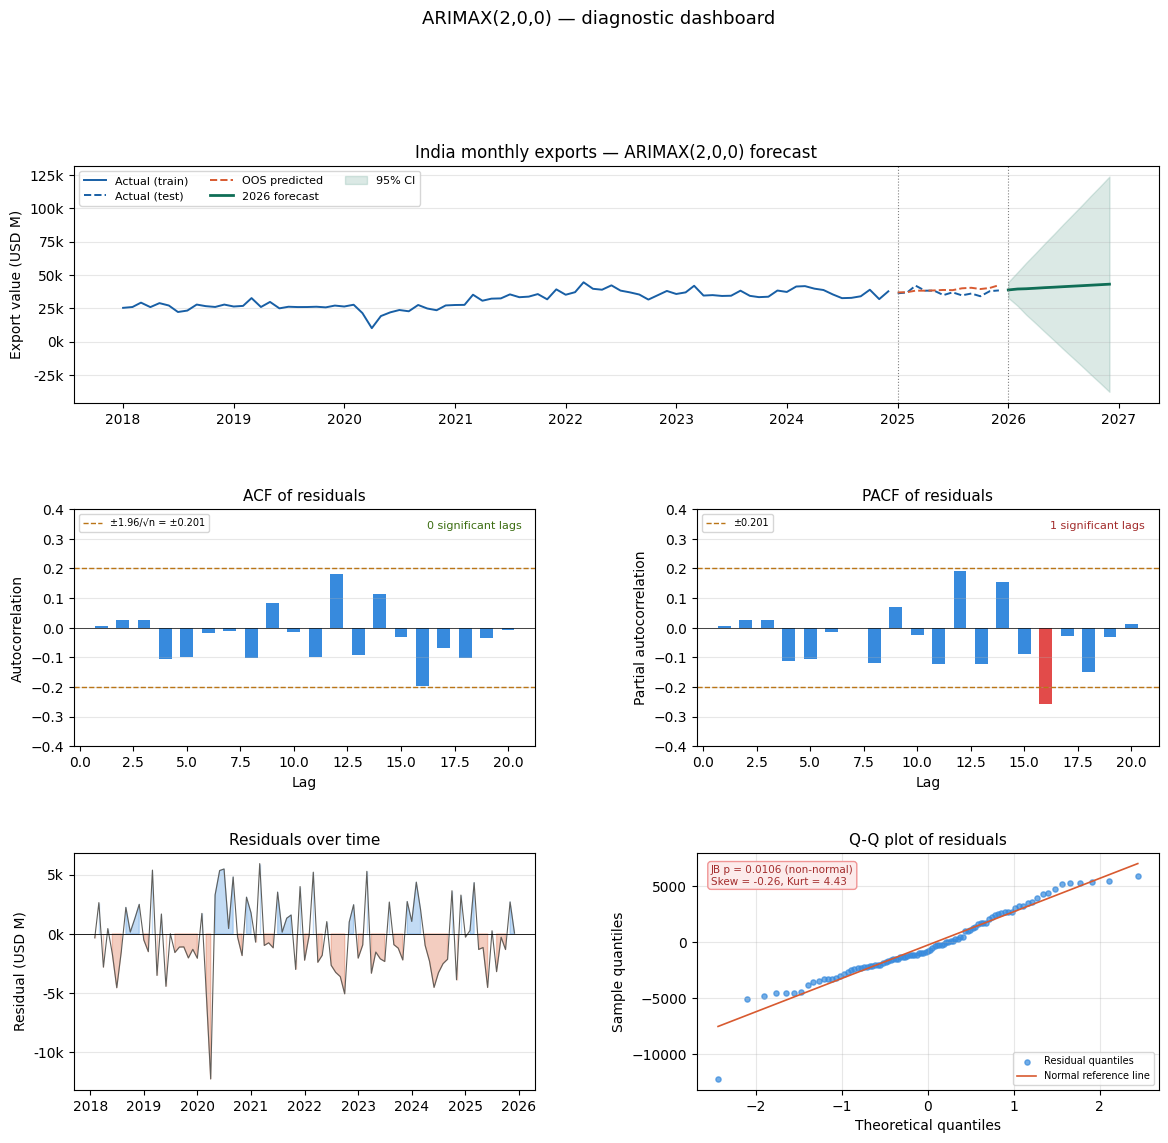

Saved: arimax_diagnostics.png


In [8]:
# =============================================================================
# PLOT 1: FORECAST CHART
# =============================================================================

fig = plt.figure(figsize=(14, 12))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

ax_fc  = fig.add_subplot(gs[0, :])   # full width — forecast
ax_acf = fig.add_subplot(gs[1, 0])   # ACF
ax_pac = fig.add_subplot(gs[1, 1])   # PACF
ax_res = fig.add_subplot(gs[2, 0])   # residual time series
ax_qq  = fig.add_subplot(gs[2, 1])   # Q-Q plot

# ── Forecast panel ──────────────────────────────────────────────────────────

train_idx = monthly.index[:-12]
test_idx  = monthly.index[-12:]

train_vals    = monthly['Export_Value'].loc[train_idx]
test_actual   = monthly['Export_Value'].loc[test_idx]

# Convert PeriodIndex to timestamps for matplotlib
def to_ts(pidx):
    return pidx.to_timestamp()

ax_fc.plot(to_ts(train_idx), train_vals.values,
           color='#185FA5', lw=1.4, label='Actual (train)')
ax_fc.plot(to_ts(test_idx), test_actual.values,
           color='#185FA5', lw=1.4, ls='--', label='Actual (test)')
ax_fc.plot(to_ts(test_idx), y_pred_oos_level,
           color='#D85A30', lw=1.4, ls='--', label='OOS predicted')

future_ts = future_periods.to_timestamp()
ax_fc.plot(future_ts, future_level.values,
           color='#0F6E56', lw=2, label='2026 forecast')
ax_fc.fill_between(future_ts, future_lo.values, future_hi.values,
                   color='#0F6E56', alpha=0.15, label='95% CI')

ax_fc.axvline(to_ts(test_idx)[0], color='gray', lw=0.8, ls=':')
ax_fc.axvline(future_ts[0],       color='gray', lw=0.8, ls=':')
ax_fc.set_title('India monthly exports — ARIMAX(2,0,0) forecast', fontsize=12)
ax_fc.set_ylabel('Export value (USD M)')
ax_fc.legend(fontsize=8, ncol=3)
ax_fc.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax_fc.grid(axis='y', alpha=0.3)

# ── ACF panel ───────────────────────────────────────────────────────────────

resid = best_fit.resid.dropna()
n_obs = len(resid)
nlags = 20
ci_bound = 1.96 / np.sqrt(n_obs)

acf_vals  = acf(resid,  nlags=nlags, fft=True)[1:]   # skip lag-0
pacf_vals = pacf(resid, nlags=nlags)[1:]

lags = np.arange(1, nlags + 1)

colors_acf  = ['#E24B4A' if abs(v) > ci_bound else '#378ADD' for v in acf_vals]
colors_pacf = ['#E24B4A' if abs(v) > ci_bound else '#378ADD' for v in pacf_vals]

ax_acf.bar(lags, acf_vals, color=colors_acf, width=0.6)
ax_acf.axhline( ci_bound, color='#BA7517', lw=1, ls='--', label=f'±1.96/√n = ±{ci_bound:.3f}')
ax_acf.axhline(-ci_bound, color='#BA7517', lw=1, ls='--')
ax_acf.axhline(0, color='black', lw=0.5)
ax_acf.set_title('ACF of residuals', fontsize=11)
ax_acf.set_xlabel('Lag')
ax_acf.set_ylabel('Autocorrelation')
ax_acf.set_ylim(-0.4, 0.4)
ax_acf.legend(fontsize=7)
ax_acf.grid(axis='y', alpha=0.3)

# Annotate: red bars signal remaining structure
n_sig_acf = sum(abs(v) > ci_bound for v in acf_vals)
ax_acf.text(0.97, 0.95, f'{n_sig_acf} significant lags',
            transform=ax_acf.transAxes, ha='right', va='top',
            fontsize=8, color='#A32D2D' if n_sig_acf > 0 else '#3B6D11')

# ── PACF panel ──────────────────────────────────────────────────────────────

ax_pac.bar(lags, pacf_vals, color=colors_pacf, width=0.6)
ax_pac.axhline( ci_bound, color='#BA7517', lw=1, ls='--', label=f'±{ci_bound:.3f}')
ax_pac.axhline(-ci_bound, color='#BA7517', lw=1, ls='--')
ax_pac.axhline(0, color='black', lw=0.5)
ax_pac.set_title('PACF of residuals', fontsize=11)
ax_pac.set_xlabel('Lag')
ax_pac.set_ylabel('Partial autocorrelation')
ax_pac.set_ylim(-0.4, 0.4)
ax_pac.legend(fontsize=7)
ax_pac.grid(axis='y', alpha=0.3)

n_sig_pacf = sum(abs(v) > ci_bound for v in pacf_vals)
ax_pac.text(0.97, 0.95, f'{n_sig_pacf} significant lags',
            transform=ax_pac.transAxes, ha='right', va='top',
            fontsize=8, color='#A32D2D' if n_sig_pacf > 0 else '#3B6D11')

# ── Residual time series ─────────────────────────────────────────────────────

resid_ts = to_ts(resid.index) # Fixed the error here

ax_res.plot(resid_ts, resid.values, color='#5F5E5A', lw=0.8)
ax_res.axhline(0, color='black', lw=0.6)
ax_res.fill_between(resid_ts, resid.values, 0,
                    where=(resid.values > 0), color='#378ADD', alpha=0.3)
ax_res.fill_between(resid_ts, resid.values, 0,
                    where=(resid.values < 0), color='#D85A30', alpha=0.3)
ax_res.set_title('Residuals over time', fontsize=11)
ax_res.set_ylabel('Residual (USD M)')
ax_res.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
ax_res.grid(axis='y', alpha=0.3)

# ── Q-Q plot ─────────────────────────────────────────────────────────────────

from scipy import stats as scipy_stats

(osm, osr), (slope, intercept, r) = scipy_stats.probplot(resid.values, dist='norm')
ax_qq.scatter(osm, osr, s=14, color='#378ADD', alpha=0.7, label='Residual quantiles')
ax_qq.plot(osm, slope * np.array(osm) + intercept,
           color='#D85A30', lw=1.2, label='Normal reference line')
ax_qq.set_title('Q-Q plot of residuals', fontsize=11)
ax_qq.set_xlabel('Theoretical quantiles')
ax_qq.set_ylabel('Sample quantiles')
ax_qq.legend(fontsize=7)
ax_qq.grid(alpha=0.3)
ax_qq.text(0.03, 0.95, f'JB p = 0.0106 (non-normal)\nSkew = -0.26, Kurt = 4.43',
           transform=ax_qq.transAxes, va='top', fontsize=7.5,
           color='#A32D2D', bbox=dict(boxstyle='round,pad=0.3', fc='#FCEBEB', ec='#F09595'))

fig.suptitle('ARIMAX(2,0,0) — diagnostic dashboard', fontsize=13, y=1.01)
plt.savefig('arimax_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: arimax_diagnostics.png")